# Exploratory Analysis on Piazza Discussion Forum Data
A work in progress

## Imports

To get the data, fill out the Piazza form on the GitHub page.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import string
from nltk.sentiment import SentimentIntensityAnalyzer
import collections

In [2]:
data = pd.read_excel("Spring 2021 Coding Results_Piazza.xlsx", sheet_name = "a4_coding1")
data.head()

,Anonymous,Post Number,Folders,Subject,Part of Post,Endorsed by Instructor,Created At,Submission HTML Removed,CP Code,Matching,Coder1,Coder2
0,no,1120,a4,Assignment 4 - Bonus Discussion,started_off_note,0.0,2020-02-24 05:06:53 UTC,Discussion of all things related to the bonus ...,0,1,0,0
1,no,1120,a4,Assignment 4 - Bonus Discussion,updated_note,0.0,2020-02-24 06:11:23 UTC,Discussion of all things related to the bonus ...,0,1,0,0
2,no,1120,a4,Assignment 4 - Bonus Discussion,followup,NaN,2020-02-28 15:41:47 UTC,What are the specifics for the Assignment 4 bo...,0,1,0,0
3,no,1120,a4,Assignment 4 - Bonus Discussion,reply_to_followup,NaN,2020-03-07 16:52:34 UTC,Still waiting for specifics...,0,1,0,0
4,no,1120,a4,Assignment 4 - Bonus Discussion,reply_to_followup,NaN,2020-03-08 20:22:06 UTC,The bonus part??will be announced tonight and ...,0,1,0,0


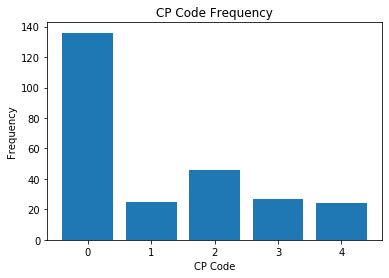

In [3]:
# Distribution of codes that we have
cp_codes = data["CP Code"]

c = collections.Counter(cp_codes)
c = sorted(c.items())
cp_num = [i[0] for i in c]
freq = [i[1] for i in c]

plt.bar(cp_num, freq)
plt.title("CP Code Frequency")
plt.xlabel("CP Code")
plt.ylabel("Frequency")
plt.show()

Cleaning steps

In [4]:
stop_words = nltk.corpus.stopwords.words('english')
def preprocess(sentence):
    words = [w for w in sentence.lower().split() if w not in stop_words]
    return [w for w in words if w not in string.punctuation]
            
posts_score = data[["Submission HTML Removed","CP Code"]].copy()
posts_score["Post_pp"] = posts_score["Submission HTML Removed"].apply(lambda x: preprocess(x))

## Word Count

Post paragraph length by CP code

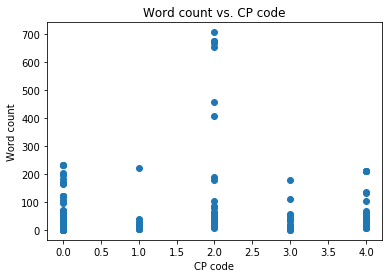

In [5]:
word_count_data = posts_score.copy()
word_count_data["Words len"] = word_count_data["Post_pp"].str.len()
not_long = word_count_data["Words len"] < 1500
word_count_data_filtered = word_count_data[not_long]

plt.scatter(word_count_data_filtered["CP Code"], word_count_data_filtered["Words len"])
plt.xlabel("CP code")
plt.ylabel("Word count")
plt.title("Word count vs. CP code")
plt.show()

## Common Words

In [6]:
# frequency of words in all posts
all_words_list = posts_score["Post_pp"].apply(pd.Series).stack().reset_index(drop=True)
fd = nltk.FreqDist(all_words_list)
words = fd.tabulate(10)

  return       ??      def    split   please       ==    class      use features     tree 
     177      148      142      112      110      105      104       99       98       97 


## Sentiment Analysis
https://www.digitalocean.com/community/tutorials/how-to-perform-sentiment-analysis-in-python-3-using-the-natural-language-toolkit-nltk

Just using the default VADER analyzer from NLTK for now, but I should create my own/adjust it.

In [7]:
# overall analysis
all_words = ' '.join(posts_score["Submission HTML Removed"])
all_words_sia = nltk.sentiment.SentimentIntensityAnalyzer().polarity_scores(all_words)
all_words_sia

{'neg': 0.031, 'neu': 0.865, 'pos': 0.104, 'compound': 1.0}

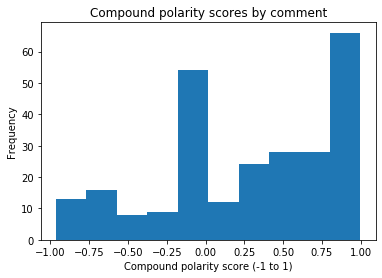

In [8]:
# analysis for each comment
sentiment_data = posts_score.copy()
sentiment_data['sentiment'] = posts_score["Submission HTML Removed"].apply(nltk.sentiment.SentimentIntensityAnalyzer().polarity_scores)
sentiments = sentiment_data['sentiment'].apply(pd.Series)
plt.hist(sentiments["compound"])
plt.xlabel("Compound polarity score (-1 to 1)")
plt.ylabel("Frequency")
plt.title("Compound polarity scores by comment")
plt.show()

## Messages over Time

## Matching Score

How often do the two scorers match? What kind of posts (by score) do they differ on?